# Task 3: Data Preprocessing and Feature Engineering

### 3.1 Import packages and locate the data

This section imports the packages required for data inspection, preprocessing, encoding, discretisation, and majority-class undersampling. It also locates the project data directory so that the notebook can run from either the repository root or the `notebooks-phase2` directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Find the project folder containing the dataset.
current_dir = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        folder
        for folder in (current_dir, *current_dir.parents)
        if (folder / "data" / "patient_data_cleaned.csv").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find data/patient_data_cleaned.csv "
        f"in {current_dir} or its parent folders."
    )

DATA_DIR = PROJECT_ROOT / "data"
CLEAN_DATA_PATH = DATA_DIR / "patient_data_cleaned.csv"

print("Project root:", PROJECT_ROOT)
print("Cleaned dataset:", CLEAN_DATA_PATH)

Project root: C:\Users\leoca\Data-Engineering-and-AI-Project
Cleaned dataset: C:\Users\leoca\Data-Engineering-and-AI-Project\data\patient_data_cleaned.csv


### 3.2 Load the cleaned Phase I dataset

The Phase I cleaned dataset is used as the starting point. Phase I already removed 2,284 exact duplicate records and created the binary `heart_disease_target`. Therefore, those cleaning steps are not repeated here.

The expected cleaned dataset contains 278,701 records and 40 columns. The target contains 272,810 class-0 records and 5,891 class-1 records. Validation checks confirm the dataset shape, missing values, exact duplicates, target values, and class distribution before preprocessing begins.

In [2]:
# loads the cleaned dataset from assignment 1
df_clean = pd.read_csv(CLEAN_DATA_PATH)

TARGET_COLUMN = "heart_disease_target"

# converts the target to numeric 0 and 1 safely
target_text = df_clean[TARGET_COLUMN].astype(str).str.strip().str.lower()
target_mapping = {
    "false": 0,
    "true": 1,
    "0": 0,
    "1": 1,
}

assert target_text.isin(target_mapping).all(), "Unexpected target value found."

df_clean[TARGET_COLUMN] = (
    target_text.map(target_mapping).astype("int8")
)

# validates the cleaned phase I artifact
print("Dataset shape:", df_clean.shape)
print("Missing values:", int(df_clean.isna().sum().sum()))
print("Exact duplicate records:", int(df_clean.duplicated().sum()))
print("\nTarget values:")
print(sorted(df_clean[TARGET_COLUMN].unique()))
print("\nTarget distribution:")
print(df_clean[TARGET_COLUMN].value_counts().sort_index())

assert df_clean.shape == (278_701, 40)
assert df_clean.isna().sum().sum() == 0
assert df_clean.duplicated().sum() == 0
assert set(df_clean[TARGET_COLUMN].unique()) == {0, 1}
assert df_clean[TARGET_COLUMN].value_counts().to_dict() == {
    0: 272_810,
    1: 5_891,
}

Dataset shape: (278701, 40)
Missing values: 0
Exact duplicate records: 0

Target values:
[np.int8(0), np.int8(1)]

Target distribution:
heart_disease_target
0    272810
1      5891
Name: count, dtype: int64


### 3.3 Create the stratified train-test split

The target is separated from the predictors before an 80/20 train-test split is created. The split is shuffled, uses `random_state=3` for reproducibility, and is stratified by the target.

Stratification preserves the approximately 2.1% heart-disease rate in both partitions. The split is performed before learned preprocessing so that information from the test set cannot influence encoders, quantile boundaries, or sampling decisions.

In [3]:
# separates the predictors and target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN].copy()

# creates a 80/20 split using stratification and shuffing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=3,
    stratify=y,
    shuffle=True,
)

# preserves the original test indices for later validation
original_test_indices = X_test.index.copy()
original_test_size = len(X_test)
original_test_distribution = y_test.value_counts().sort_index().to_dict()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

print("\nTraining positive rate:")
print(f"{y_train.mean():.4%}")

print("\nTesting positive rate:")
print(f"{y_test.mean():.4%}")

assert len(X_train) + len(X_test) == len(df_clean)
assert X_train.index.intersection(X_test.index).empty
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

Training shape: (222960, 39)
Testing shape: (55741, 39)

Training target distribution:
heart_disease_target
0    218247
1      4713
Name: count, dtype: int64

Testing target distribution:
heart_disease_target
0    54563
1     1178
Name: count, dtype: int64

Training positive rate:
2.1138%

Testing positive rate:
2.1133%


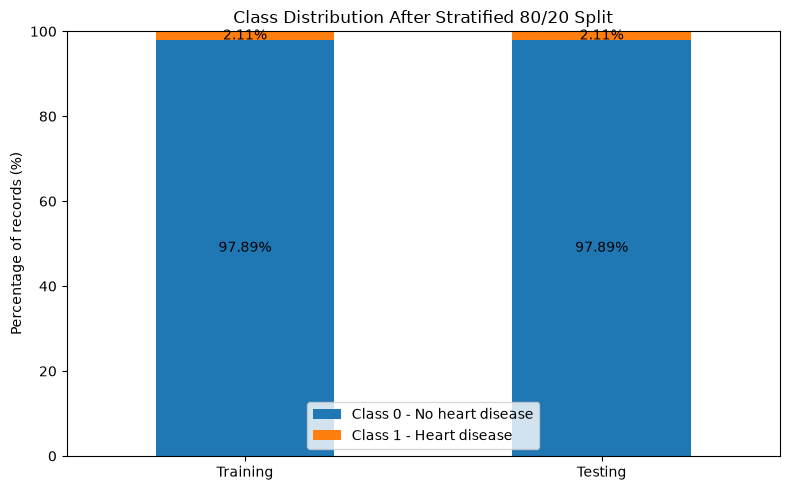

In [19]:
# visualises how stratification preserved the target distribution
split_distribution = pd.DataFrame({
    "Training": y_train.value_counts(normalize=True).sort_index() * 100,
    "Testing": y_test.value_counts(normalize=True).sort_index() * 100,
}).T

split_distribution.columns = [
    "Class 0 - No heart disease",
    "Class 1 - Heart disease",
]

ax = split_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
)

ax.set_title("Class Distribution After Stratified 80/20 Split")
ax.set_ylabel("Percentage of records (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

# displays the class percentages on each bar
for i, dataset in enumerate(["Training", "Testing"]):
    negative_rate = split_distribution.loc[
        dataset, "Class 0 - No heart disease"
    ]
    positive_rate = split_distribution.loc[
        dataset, "Class 1 - Heart disease"
    ]

    ax.text(
        i,
        negative_rate / 2,
        f"{negative_rate:.2f}%",
        ha="center",
        va="center",
    )

    ax.text(
        i,
        negative_rate + positive_rate / 2,
        f"{positive_rate:.2f}%",
        ha="center",
        va="center",
    )

plt.legend(loc="lower center")
plt.tight_layout()
plt.show()

### 3.4 Remove target-leakage columns

The columns `sublabel`, `disease_flags`, `heart_disease`, and `label` are excluded because they contain complete or partial information about the target.

The target was constructed directly from `sublabel`, while `disease_flags` represents disease combinations. The existing `heart_disease` attribute is strongly associated with the constructed target, and `label` indicates whether any disease is present. Retaining these attributes could allow the model to infer the answer instead of learning clinically meaningful relationships.

In [4]:
# removes attributes that contain information relating to the target
leakage_columns = [
    "sublabel",
    "disease_flags",
    "heart_disease",
    "label",
]

X_train = X_train.drop(columns=leakage_columns)
X_test = X_test.drop(columns=leakage_columns)

print("Removed target-leakage columns:", leakage_columns)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

assert not set(leakage_columns).intersection(X_train.columns)
assert list(X_train.columns) == list(X_test.columns)

Removed target-leakage columns: ['sublabel', 'disease_flags', 'heart_disease', 'label']
Training shape: (222960, 35)
Testing shape: (55741, 35)


### 3.5 Remove redundant and provenance columns

Several additional attributes are removed before modelling:

- `composite_key` repeats information already represented by other predictors.
- `age_level` and `age_normalized` duplicate information contained in `age`.
- `bmi` is removed because the existing `bmi_level` provides clinically interpretable WHO-style categories.
- `source_dataset` identifies the original dataset from which a record was obtained.

The three source datasets have substantially different heart-disease rates. Retaining `source_dataset` could allow the model to learn dataset origin rather than clinically meaningful patient patterns. Its removal therefore reduces the risk of provenance leakage and improves the practical meaning of the resulting rules.

In [5]:
# removes redundant attributes and dataset provenance
redundant_and_provenance_columns = [
    "composite_key",
    "source_dataset",
    "age_level",
    "age_normalized",
    "bmi",
]

X_train = X_train.drop(columns=redundant_and_provenance_columns)
X_test = X_test.drop(columns=redundant_and_provenance_columns)

print(
    "Removed redundant and provenance columns:",
    redundant_and_provenance_columns,
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nRemaining columns:")
print(X_train.columns.tolist())

assert not set(redundant_and_provenance_columns).intersection(
    X_train.columns
)
assert list(X_train.columns) == list(X_test.columns)

Removed redundant and provenance columns: ['composite_key', 'source_dataset', 'age_level', 'age_normalized', 'bmi']
Training shape: (222960, 30)
Testing shape: (55741, 30)

Remaining columns:
['gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'hypertension', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status']


### 3.6 Validate the cleaned training and testing partitions

The training and testing partitions are checked for missing values, column alignment, data types, and identical predictor profiles.

The 2,284 exact duplicate records found in the raw dataset were already removed during Phase I. However, some rows may become identical after leakage, redundant, and provenance columns are removed. These are described as duplicate predictor profiles rather than raw duplicate records.

Duplicate predictor profiles are retained because different patients can share the same retained predictors. Some identical predictor profiles may also have different target outcomes, so automatically deleting them could remove valid observations or alter the class distribution.

In [6]:
# checks the missing values and column alignment
print("Training missing values:", int(X_train.isna().sum().sum()))
print("Testing missing values:", int(X_test.isna().sum().sum()))
print(
    "Training and testing columns aligned:",
    list(X_train.columns) == list(X_test.columns),
)

# counts the rows that belong to repeated predictor profiles
train_duplicate_mask = X_train.duplicated(keep=False)
test_duplicate_mask = X_test.duplicated(keep=False)

print(
    "\nTraining rows in duplicate predictor profiles:",
    int(train_duplicate_mask.sum()),
)
print(
    "Testing rows in duplicate predictor profiles:",
    int(test_duplicate_mask.sum()),
)

# determines whether the repeated training profiles have conflicting targets
train_profile_data = X_train.copy()
train_profile_data["_target"] = y_train

profile_summary = (
    train_profile_data
    .groupby(list(X_train.columns), dropna=False)["_target"]
    .agg(profile_size="size", target_count="nunique")
    .reset_index()
)

repeated_profiles = profile_summary[
    profile_summary["profile_size"] > 1
]
conflicting_profiles = repeated_profiles[
    repeated_profiles["target_count"] > 1
]

print("Repeated training profiles:", len(repeated_profiles))
print(
    "Repeated profiles with different target outcomes:",
    len(conflicting_profiles),
)

print("\nTraining data types:")
print(X_train.dtypes.value_counts())

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert list(X_train.columns) == list(X_test.columns)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

Training missing values: 0
Testing missing values: 0
Training and testing columns aligned: True

Training rows in duplicate predictor profiles: 25812
Testing rows in duplicate predictor profiles: 2078
Repeated training profiles: 11285
Repeated profiles with different target outcomes: 707

Training data types:
float64    16
str        13
int64       1
Name: count, dtype: int64


### 3.7 Check for invalid values

Selected numerical attributes are checked using their minimum and maximum values. This helps identify impossible values such as negative ages or negative clinical measurements.

This check is separate from the outlier investigation. An extreme value may still be valid, while an invalid value represents an impossible or incorrectly recorded measurement. This section only inspects the data and does not remove or transform any records.

In [7]:
# Selects the main numerical attributes for the invalid-value check.
columns_to_check = [
    "age",
    "hypertension",
    "HbA1c_level",
    "glucose",
    "cholesterol",
    "sleep_hours",
    "triglycerides",
    "crp_level",
    "homocysteine_level",
    "systolic_bp",
    "diastolic_bp",
    "alcohol_intake",
    "salt_intake",
    "heart_rate",
    "hdl",
    "ldl",
]

# Displays the minimum and maximum of each selected attribute.
invalid_value_summary = X_train[columns_to_check].agg(["min", "max"]).transpose()
invalid_value_summary.columns = ["Minimum", "Maximum"]
display(invalid_value_summary)

# Checks for negative values in measurements that should not be negative.
negative_value_counts = (X_train[columns_to_check] < 0).sum()

print("Negative values found:")
print(negative_value_counts[negative_value_counts > 0])

if (negative_value_counts > 0).any():
    print("Negative values require further investigation.")
else:
    print("No negative numerical values were found.")

,Minimum,Maximum
age,2.000000,89.000000
hypertension,0.000000,1.000000
HbA1c_level,3.500000,9.000000
glucose,70.000000,300.000000
cholesterol,150.000000,300.000000
sleep_hours,4.000000,10.000000
triglycerides,50.000000,400.000000
crp_level,0.003647,14.996625
homocysteine_level,5.000236,19.999037
systolic_bp,90.000000,179.000000


Negative values found:
Series([], dtype: int64)
No negative numerical values were found.


### 3.8 Investigate numerical outliers

The interquartile range method is used to flag unusual numerical values for investigation. A value is flagged when it falls below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`.

An IQR flag does not prove that a value is incorrect. The flagged values are therefore reviewed alongside their distributions and plausible ranges. They are retained unless there is evidence that they are data-entry errors or medically impossible values. No rows are automatically removed, capped, or transformed solely because they are statistical outliers.

,feature,minimum,maximum,iqr_lower_bound,iqr_upper_bound,flagged_records
0,age,2.000000,89.000000,-22.000000,122.000000,0
1,hypertension,0.000000,1.000000,-0.325594,0.542657,6454
2,HbA1c_level,3.500000,9.000000,3.170101,9.083164,0
3,glucose,70.000000,300.000000,10.000000,250.000000,1624
4,cholesterol,150.000000,300.000000,138.000000,306.000000,0
5,sleep_hours,4.000000,10.000000,3.950000,9.950000,1216
6,triglycerides,50.000000,400.000000,-42.625000,412.375000,0
7,blood_pressure,120.000000,180.000000,146.284659,153.382711,24303
8,crp_level,0.003647,14.996625,6.599316,8.454110,24155
9,homocysteine_level,5.000236,19.999037,11.690145,13.283792,24774


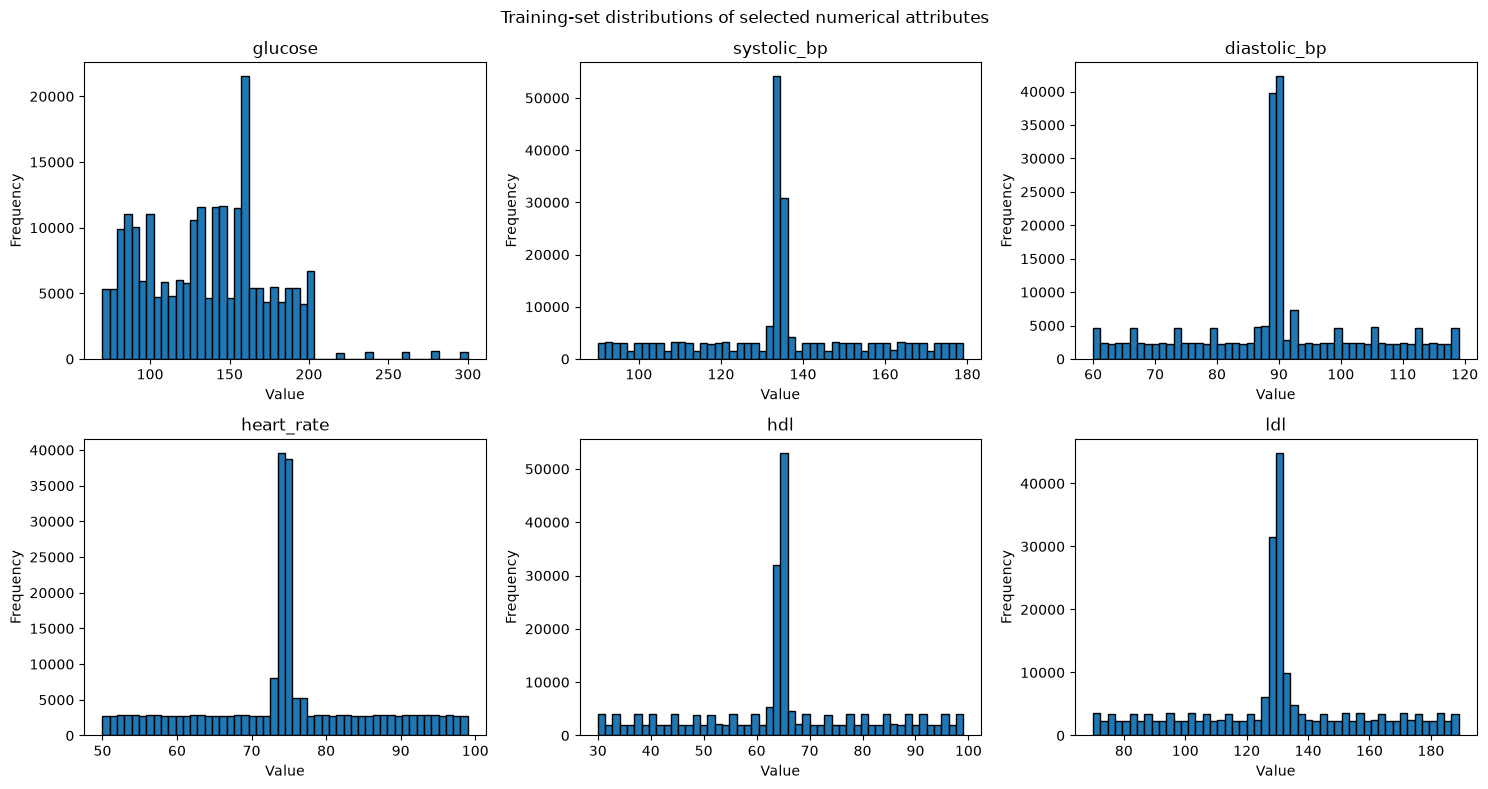

Flagged values are retained because an IQR flag alone does not establish that a record is invalid.


In [8]:
# selects the numerical attributes before encoding and discretisation
numerical_columns = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

outlier_rows = []

# calculates the training-based IQR boundaries
for column in numerical_columns:
    q1 = X_train[column].quantile(0.25)
    q3 = X_train[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flagged_count = (
        (X_train[column] < lower_bound)
        | (X_train[column] > upper_bound)
    ).sum()

    outlier_rows.append(
        {
            "feature": column,
            "minimum": X_train[column].min(),
            "maximum": X_train[column].max(),
            "iqr_lower_bound": lower_bound,
            "iqr_upper_bound": upper_bound,
            "flagged_records": int(flagged_count),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

# plots the selected clinical attributes for distribution review.
plot_columns = [
    "glucose",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "hdl",
    "ldl",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for axis, column in zip(axes.flatten(), plot_columns):
    axis.hist(X_train[column], bins=50, edgecolor="black")
    axis.set_title(column)
    axis.set_xlabel("Value")
    axis.set_ylabel("Frequency")

plt.suptitle("Training-set distributions of selected numerical attributes")
plt.tight_layout()
plt.show()

print(
    "Flagged values are retained because an IQR flag alone "
    "does not establish that a record is invalid."
)

### 3.9 Encode binary attributes

Binary categorical attributes are converted using fixed and transparent 0/1 mappings. The same mappings are applied to the training and testing partitions, so no categories are learned from the test data.

Any unexpected value would produce a missing value and be detected by the later validation checks.

In [9]:
# defines the fixed binary mappings
binary_mappings = {
    "gender": {
        "Female": 0,
        "Male": 1,
    },
    "diabetes": {
        "No": 0,
        "Yes": 1,
    },
    "family_history": {
        "No": 0,
        "Yes": 1,
    },
    "low_hdl_cholesterol": {
        "No": 0,
        "Yes": 1,
    },
    "high_ldl_cholesterol": {
        "No": 0,
        "Yes": 1,
    },
    "high_blood_pressure": {
        "No": 0,
        "Yes": 1,
    },
}

# applies the fixed mappings to both partitions
for column, mapping in binary_mappings.items():
    X_train[column] = X_train[column].map(mapping)
    X_test[column] = X_test[column].map(mapping)

binary_columns = list(binary_mappings)

print("Encoded binary attributes:", binary_columns)
display(X_train[binary_columns].head())

assert X_train[binary_columns].isna().sum().sum() == 0
assert X_test[binary_columns].isna().sum().sum() == 0

Encoded binary attributes: ['gender', 'diabetes', 'family_history', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure']


,gender,diabetes,family_history,low_hdl_cholesterol,high_ldl_cholesterol,high_blood_pressure
226737,1,1,0,0,0,0
240229,0,0,1,0,1,0
263800,1,0,0,0,0,1
102871,1,1,1,0,1,0
209771,0,1,0,0,0,1


### 3.10 Encode ordered categorical attributes

Ordered categorical attributes are encoded according to their meaningful category order. The `OrdinalEncoder` is fitted using the training partition only and then applied to the unchanged testing partition.

Smoking is not included here because `Never`, `Former`, and `Current` do not form a reliable single risk scale. It is treated as a nominal attribute in the next section.

In [10]:
# defines the ordered categorical attributes and their category order.
ordinal_columns = [
    "bmi_level",
    "physical_activity",
    "stress_level",
    "sugar_consumption",
    "education_level",
]

ordinal_categories = [
    ["Underweight", "Normal", "Overweight", "Obese"],
    ["Low", "Moderate", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Primary", "Secondary", "Tertiary"],
]

# fit only on the training data
ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    dtype=np.int16,
)

X_train[ordinal_columns] = ordinal_encoder.fit_transform(
    X_train[ordinal_columns]
)

# applies the fitted encoder to the test data
X_test[ordinal_columns] = ordinal_encoder.transform(
    X_test[ordinal_columns]
)

print("Encoded ordinal attributes:", ordinal_columns)
display(X_train[ordinal_columns].head())

Encoded ordinal attributes: ['bmi_level', 'physical_activity', 'stress_level', 'sugar_consumption', 'education_level']


,bmi_level,physical_activity,stress_level,sugar_consumption,education_level
226737,3,1,0,1,1
240229,0,0,1,2,0
263800,2,0,1,2,0
102871,3,1,2,2,2
209771,0,1,1,1,0


### 3.11 One-hot encode nominal attributes

`smoking` and `employment_status` are treated as nominal variables because their categories should not be represented as a single ordered numerical scale.

The one-hot encoder is fitted using training data only. The fitted encoder is then applied to the test data. `handle_unknown="ignore"` ensures that an unseen test category does not change the column structure.

In [11]:
# defines the nominal attributes
nominal_columns = [
    "smoking",
    "employment_status",
]

# fits the one-hot encoder using training data only
one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.int8,
)

train_one_hot_array = one_hot_encoder.fit_transform(
    X_train[nominal_columns]
)
test_one_hot_array = one_hot_encoder.transform(
    X_test[nominal_columns]
)

one_hot_columns = one_hot_encoder.get_feature_names_out(
    nominal_columns
)

# creates the DataFrames while preserving the original row indices
train_one_hot = pd.DataFrame(
    train_one_hot_array,
    columns=one_hot_columns,
    index=X_train.index,
)

test_one_hot = pd.DataFrame(
    test_one_hot_array,
    columns=one_hot_columns,
    index=X_test.index,
)

# removes the original nominal columns and add encoded columns
X_train = pd.concat(
    [
        X_train.drop(columns=nominal_columns),
        train_one_hot,
    ],
    axis=1,
)

X_test = pd.concat(
    [
        X_test.drop(columns=nominal_columns),
        test_one_hot,
    ],
    axis=1,
)

print("One-hot encoded attributes:", nominal_columns)
print("Created columns:", one_hot_columns.tolist())
display(X_train[one_hot_columns].head())
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

assert list(X_train.columns) == list(X_test.columns)

One-hot encoded attributes: ['smoking', 'employment_status']
Created columns: ['smoking_Current', 'smoking_Former', 'smoking_Never', 'employment_status_Employed', 'employment_status_Retired', 'employment_status_Unemployed']


,smoking_Current,smoking_Former,smoking_Never,employment_status_Employed,employment_status_Retired,employment_status_Unemployed
226737,0,0,1,0,0,1
240229,0,1,0,0,0,1
263800,1,0,0,0,1,0
102871,1,0,0,0,0,1
209771,0,0,1,0,0,1


Training shape: (222960, 34)
Testing shape: (55741, 34)


### 3.12 Discretise fixed-boundary numerical attributes

Selected numerical attributes are discretised using fixed, interpretable boundaries. eLCS supports both continuous and discrete attributes; therefore, this step is not required for basic compatibility.

Discretisation is used here to reduce the search space, encourage more compact rules, and improve the interpretability of the learned conditions. The original numerical attributes are retained temporarily until the new binned attributes have been validated and encoded.

The intervals use `right=False`. This means that a boundary value begins the following category. For example, a glucose value of 126 is assigned to `Diabetes`, rather than `Prediabetes`.

In [12]:
# defines the fixed boundaries and ordered labels
fixed_bin_definitions = {
    "glucose": {
        "bins": [-np.inf, 100, 126, np.inf],
        "labels": ["Normal", "Prediabetes", "Diabetes"],
    },
    "cholesterol": {
        "bins": [-np.inf, 200, 240, np.inf],
        "labels": ["Desirable", "Borderline", "High"],
    },
    "systolic_bp": {
        "bins": [-np.inf, 120, 130, 140, np.inf],
        "labels": ["Normal", "Elevated", "Stage1", "Stage2"],
    },
    "diastolic_bp": {
        "bins": [-np.inf, 80, 90, np.inf],
        "labels": ["Normal", "Stage1", "Stage2"],
    },
    "HbA1c_level": {
        "bins": [-np.inf, 5.7, 6.5, np.inf],
        "labels": ["Normal", "Prediabetes", "Diabetes"],
    },
    "age": {
        "bins": [-np.inf, 18, 40, 60, np.inf],
        "labels": ["Child", "YoungAdult", "MiddleAged", "Senior"],
    },
    "triglycerides": {
        "bins": [-np.inf, 150, 200, 500, np.inf],
        "labels": [
            "Normal",
            "BorderlineHigh",
            "High",
            "VeryHigh",
        ],
    },
    "hdl": {
        "bins": [-np.inf, 40, 60, np.inf],
        "labels": ["Low", "Normal", "High"],
    },
    "ldl": {
        "bins": [-np.inf, 100, 130, 160, 190, np.inf],
        "labels": [
            "Optimal",
            "NearOptimal",
            "BorderlineHigh",
            "High",
            "VeryHigh",
        ],
    },
    "heart_rate": {
        "bins": [-np.inf, 60, 100, np.inf],
        "labels": ["Low", "Normal", "High"],
    },
    "crp_level": {
        "bins": [-np.inf, 1, 3, np.inf],
        "labels": ["Low", "Average", "High"],
    },
    "sleep_hours": {
        "bins": [-np.inf, 7, 9, np.inf],
        "labels": ["Short", "Recommended", "Long"],
    },
    "homocysteine_level": {
        "bins": [-np.inf, 15, 30, np.inf],
        "labels": ["Normal", "Elevated", "High"],
    },
}

# applies the same fixed boundaries to both partitions
for column, definition in fixed_bin_definitions.items():
    binned_column = f"{column}_binned"

    X_train[binned_column] = pd.cut(
        X_train[column],
        bins=definition["bins"],
        labels=definition["labels"],
        right=False,
        include_lowest=True,
    )

    X_test[binned_column] = pd.cut(
        X_test[column],
        bins=definition["bins"],
        labels=definition["labels"],
        right=False,
        include_lowest=True,
    )

fixed_binned_columns = [
    f"{column}_binned"
    for column in fixed_bin_definitions
]

print("Created fixed-boundary attributes:")
print(fixed_binned_columns)

print("\nTraining missing binned values:")
print(X_train[fixed_binned_columns].isna().sum())

print("\nTesting missing binned values:")
print(X_test[fixed_binned_columns].isna().sum())

assert X_train[fixed_binned_columns].isna().sum().sum() == 0
assert X_test[fixed_binned_columns].isna().sum().sum() == 0

Created fixed-boundary attributes:
['glucose_binned', 'cholesterol_binned', 'systolic_bp_binned', 'diastolic_bp_binned', 'HbA1c_level_binned', 'age_binned', 'triglycerides_binned', 'hdl_binned', 'ldl_binned', 'heart_rate_binned', 'crp_level_binned', 'sleep_hours_binned', 'homocysteine_level_binned']

Training missing binned values:
glucose_binned               0
cholesterol_binned           0
systolic_bp_binned           0
diastolic_bp_binned          0
HbA1c_level_binned           0
age_binned                   0
triglycerides_binned         0
hdl_binned                   0
ldl_binned                   0
heart_rate_binned            0
crp_level_binned             0
sleep_hours_binned           0
homocysteine_level_binned    0
dtype: int64

Testing missing binned values:
glucose_binned               0
cholesterol_binned           0
systolic_bp_binned           0
diastolic_bp_binned          0
HbA1c_level_binned           0
age_binned                   0
triglycerides_binned         0
h

### 3.13 Discretise training-based numerical attributes

The attributes `hypertension`, `alcohol_intake`, and `salt_intake` do not have suitable fixed boundaries for their representation in this dataset. They are divided into three relative levels using quantile boundaries learned from the training partition.

The test data does not contribute to the boundary calculation. The first and final boundaries are extended to negative and positive infinity so that every possible test value can be assigned to a category.

In [13]:
# attributes that use the training-derived quantile boundaries
quantile_columns = [
    "hypertension",
    "alcohol_intake",
    "salt_intake",
]

quantile_labels = ["Low", "Medium", "High"]
quantile_boundaries = {}

for column in quantile_columns:
    # learns the two internal boundaries from training data only
    internal_boundaries = (
        X_train[column]
        .quantile([1 / 3, 2 / 3])
        .to_numpy()
    )

    # ensures that the two learned boundaries are distinct
    assert (
        internal_boundaries[0] < internal_boundaries[1]
    ), f"Non-unique quantile boundaries found for {column}."

    bin_edges = np.array(
        [
            -np.inf,
            internal_boundaries[0],
            internal_boundaries[1],
            np.inf,
        ]
    )

    quantile_boundaries[column] = bin_edges

    binned_column = f"{column}_binned"

    X_train[binned_column] = pd.cut(
        X_train[column],
        bins=bin_edges,
        labels=quantile_labels,
        right=False,
        include_lowest=True,
    )

    X_test[binned_column] = pd.cut(
        X_test[column],
        bins=bin_edges,
        labels=quantile_labels,
        right=False,
        include_lowest=True,
    )

quantile_binned_columns = [
    f"{column}_binned"
    for column in quantile_columns
]

print("Training-derived quantile boundaries:")

for column, boundaries in quantile_boundaries.items():
    print(
        f"{column}: "
        f"{boundaries[1]:.6f}, {boundaries[2]:.6f}"
    )

print("\nTraining category counts:")

for column in quantile_binned_columns:
    print(f"\n{column}")
    print(X_train[column].value_counts().sort_index())

assert X_train[quantile_binned_columns].isna().sum().sum() == 0
assert X_test[quantile_binned_columns].isna().sum().sum() == 0

Training-derived quantile boundaries:
hypertension: 0.000000, 0.166667
alcohol_intake: 14.676574, 15.400000
salt_intake: 8.284518, 8.685304

Training category counts:

hypertension_binned
hypertension_binned
Low            0
Medium    148311
High       74649
Name: count, dtype: int64

alcohol_intake_binned
alcohol_intake_binned
Low       74317
Medium    74293
High      74350
Name: count, dtype: int64

salt_intake_binned
salt_intake_binned
Low       72047
Medium    73939
High      76974
Name: count, dtype: int64


### 3.14 Encode the newly binned attributes

The newly created interval labels are ordered categories. An `OrdinalEncoder` is fitted on the training bins and applied to the testing bins.

The category order is explicitly supplied so that the numerical codes represent the intended progression rather than an alphabetical ordering.

In [14]:
# combines the fixed and quantile-based category definitions
binned_category_orders = {
    f"{column}_binned": definition["labels"]
    for column, definition in fixed_bin_definitions.items()
}

for column in quantile_columns:
    binned_category_orders[f"{column}_binned"] = quantile_labels

binned_columns = list(binned_category_orders)
binned_categories = [
    binned_category_orders[column]
    for column in binned_columns
]

# fits the binned encoder using training data only
binned_encoder = OrdinalEncoder(
    categories=binned_categories,
    dtype=np.int16,
)

X_train[binned_columns] = binned_encoder.fit_transform(
    X_train[binned_columns]
)

# applies the fitted encoder to test data
X_test[binned_columns] = binned_encoder.transform(
    X_test[binned_columns]
)

print("Encoded binned attributes:")
print(binned_columns)

display(X_train[binned_columns].head())

Encoded binned attributes:
['glucose_binned', 'cholesterol_binned', 'systolic_bp_binned', 'diastolic_bp_binned', 'HbA1c_level_binned', 'age_binned', 'triglycerides_binned', 'hdl_binned', 'ldl_binned', 'heart_rate_binned', 'crp_level_binned', 'sleep_hours_binned', 'homocysteine_level_binned', 'hypertension_binned', 'alcohol_intake_binned', 'salt_intake_binned']


,glucose_binned,cholesterol_binned,systolic_bp_binned,diastolic_bp_binned,HbA1c_level_binned,age_binned,triglycerides_binned,hdl_binned,ldl_binned,heart_rate_binned,crp_level_binned,sleep_hours_binned,homocysteine_level_binned,hypertension_binned,alcohol_intake_binned,salt_intake_binned
226737,2,0,3,2,2,3,0,2,1,1,2,0,0,2,2,2
240229,2,0,2,0,0,1,0,2,3,1,2,0,0,1,0,0
263800,2,0,0,2,0,2,2,2,0,1,2,1,0,1,2,1
102871,2,1,2,1,2,2,2,2,2,1,2,0,0,2,1,1
209771,0,2,3,1,2,1,2,2,0,1,2,0,0,1,0,2


### 3.15 Remove the original attributes replaced by bins

After the encoded binned attributes have been created successfully, their original numerical versions are removed. This prevents each measurement from appearing twice and avoids increasing the eLCS search space with redundant representations.

The `blood_pressure` attribute is not included in this list because it was not replaced by one of the newly created bins. It remains as a continuous numerical predictor, which eLCS can process.

In [15]:
# removes only the numerical attributes that now have encoded bins
replaced_numerical_columns = (
    list(fixed_bin_definitions)
    + quantile_columns
)

X_train = X_train.drop(
    columns=replaced_numerical_columns
)

X_test = X_test.drop(
    columns=replaced_numerical_columns
)

print(
    "Removed original attributes replaced by bins:",
    replaced_numerical_columns,
)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

assert not set(replaced_numerical_columns).intersection(
    X_train.columns
)
assert list(X_train.columns) == list(X_test.columns)

Removed original attributes replaced by bins: ['glucose', 'cholesterol', 'systolic_bp', 'diastolic_bp', 'HbA1c_level', 'age', 'triglycerides', 'hdl', 'ldl', 'heart_rate', 'crp_level', 'sleep_hours', 'homocysteine_level', 'hypertension', 'alcohol_intake', 'salt_intake']
Training shape: (222960, 34)
Testing shape: (55741, 34)


### 3.16 Validate the full preprocessed dataset

The completed preprocessing pipeline is validated before any class-imbalance treatment is applied.

The checks confirm that:

- training and testing contain identical predictor columns;
- all predictors are numerical;
- there are no missing or infinite values;
- predictor and target indices remain aligned;
- the test partition contains the same records and class distribution produced by the original split.

This full preprocessed training set is required for the original-eLCS-on-preprocessed-data comparison in Task 4.

In [16]:
# ensures the column order is identical
X_test = X_test.reindex(columns=X_train.columns)

# confirms that all values are numerical
non_numeric_train = X_train.select_dtypes(
    exclude=[np.number]
).columns.tolist()

non_numeric_test = X_test.select_dtypes(
    exclude=[np.number]
).columns.tolist()

# checks missing and infinite values
train_missing = int(X_train.isna().sum().sum())
test_missing = int(X_test.isna().sum().sum())

train_infinite = int(
    np.isinf(X_train.to_numpy(dtype=float)).sum()
)
test_infinite = int(
    np.isinf(X_test.to_numpy(dtype=float)).sum()
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Columns aligned:", list(X_train.columns) == list(X_test.columns))
print("Non-numeric training columns:", non_numeric_train)
print("Non-numeric testing columns:", non_numeric_test)
print("Training missing values:", train_missing)
print("Testing missing values:", test_missing)
print("Training infinite values:", train_infinite)
print("Testing infinite values:", test_infinite)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

assert list(X_train.columns) == list(X_test.columns)
assert not non_numeric_train
assert not non_numeric_test
assert train_missing == 0
assert test_missing == 0
assert train_infinite == 0
assert test_infinite == 0
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert X_test.index.equals(original_test_indices)
assert len(X_test) == original_test_size
assert (
    y_test.value_counts().sort_index().to_dict()
    == original_test_distribution
)

Training shape: (222960, 34)
Testing shape: (55741, 34)
Columns aligned: True
Non-numeric training columns: []
Non-numeric testing columns: []
Training missing values: 0
Testing missing values: 0
Training infinite values: 0
Testing infinite values: 0

Training target distribution:
heart_disease_target
0    218247
1      4713
Name: count, dtype: int64

Testing target distribution:
heart_disease_target
0    54563
1     1178
Name: count, dtype: int64


### 3.17 Preserve the full preprocessed training set

A separate copy of the complete preprocessed training partition is retained before undersampling.

This version remains imbalanced and will be used in Task 4 to evaluate the original eLCS on preprocessed data using its default parameters. Preserving it allows the effect of preprocessing to be evaluated separately from the effect of majority-class undersampling.

In [17]:
# preserves independent copies of the full preprocessed partitions
X_train_full = X_train.copy()
y_train_full = y_train.copy()

X_test_preprocessed = X_test.copy()
y_test_preprocessed = y_test.copy()

print("Full training shape:", X_train_full.shape)
print("Testing shape:", X_test_preprocessed.shape)

print("\nFull training target distribution:")
print(y_train_full.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test_preprocessed.value_counts().sort_index())

assert len(X_train_full) == len(y_train_full)
assert len(X_test_preprocessed) == len(y_test_preprocessed)

Full training shape: (222960, 34)
Testing shape: (55741, 34)

Full training target distribution:
heart_disease_target
0    218247
1      4713
Name: count, dtype: int64

Testing target distribution:
heart_disease_target
0    54563
1     1178
Name: count, dtype: int64


### 3.18 Reduce the majority class in the training data

The training data has a severe class imbalance, with approximately 97.9% of records belonging to class 0. The original eLCS baseline consequently predicted only the majority class.

Random majority-class undersampling is applied to the training partition only. Every class-1 training record is retained, while class 0 is reduced to 25,000 records. No synthetic records are created.

The resulting training data is not completely balanced. It contains approximately 5.3 class-0 records for every class-1 record. The unchanged test partition retains the original class distribution so that evaluation reflects performance on the real dataset distribution.

In [18]:
from imblearn.under_sampling import RandomUnderSampler

# retains all of the positive records and select 25,000 negatives records
positive_training_count = int((y_train_full == 1).sum())

sampling_strategy = {
    0: 25_000,
    1: positive_training_count,
}

under_sampler = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=3,
)

X_train_undersampled, y_train_undersampled = (
    under_sampler.fit_resample(
        X_train_full,
        y_train_full,
    )
)

# resets the indices for clean CSV output and row alignment
X_train_undersampled = (
    X_train_undersampled.reset_index(drop=True)
)
y_train_undersampled = (
    y_train_undersampled.reset_index(drop=True)
)

print("Undersampled training shape:", X_train_undersampled.shape)
print("\nUndersampled target distribution:")
print(y_train_undersampled.value_counts().sort_index())

negative_count = int((y_train_undersampled == 0).sum())
positive_count = int((y_train_undersampled == 1).sum())

print(
    "\nNegative-to-positive ratio:",
    f"{negative_count / positive_count:.2f}:1",
)

ModuleNotFoundError: No module named 'imblearn'

### 3.19 Validate the undersampled training data

The undersampling result is checked to confirm that it contains exactly 25,000 class-0 records and every class-1 training record.

Additional checks confirm that the predictor columns remain unchanged, no missing or infinite values were introduced, and the test partition was not sampled or otherwise modified.

In [ ]:
# validates the undersampled training distribution
undersampled_distribution = (
    y_train_undersampled
    .value_counts()
    .sort_index()
    .to_dict()
)

undersampled_missing = int(
    X_train_undersampled.isna().sum().sum()
)

undersampled_infinite = int(
    np.isinf(
        X_train_undersampled.to_numpy(dtype=float)
    ).sum()
)

print("Undersampled shape:", X_train_undersampled.shape)
print("Undersampled distribution:", undersampled_distribution)
print("Missing values:", undersampled_missing)
print("Infinite values:", undersampled_infinite)

print("\nUnchanged test shape:", X_test_preprocessed.shape)
print(
    "Unchanged test distribution:",
    y_test_preprocessed.value_counts().sort_index().to_dict(),
)

assert undersampled_distribution[0] == 25_000
assert undersampled_distribution[1] == positive_training_count
assert len(X_train_undersampled) == (
    25_000 + positive_training_count
)
assert list(X_train_undersampled.columns) == list(
    X_train_full.columns
)
assert undersampled_missing == 0
assert undersampled_infinite == 0
assert len(X_train_undersampled) == len(
    y_train_undersampled
)

# confirms that the test partition remains unchanged
assert X_test_preprocessed.index.equals(
    original_test_indices
)
assert len(X_test_preprocessed) == original_test_size
assert (
    y_test_preprocessed
    .value_counts()
    .sort_index()
    .to_dict()
    == original_test_distribution
)

print("\nAll undersampling checks passed.")
print("The test set was not sampled or modified.")

Undersampled shape: (29713, 34)
Undersampled distribution: {0: 25000, 1: 4713}
Missing values: 0
Infinite values: 0

Unchanged test shape: (55741, 34)
Unchanged test distribution: {0: 54563, 1: 1178}

All undersampling checks passed.
The test set was not sampled or modified.


### 3.20 Save the preprocessed datasets

Both versions of the training data are saved:

1. The full preprocessed and imbalanced training set.
2. The preprocessed training set containing 25,000 class-0 records and every class-1 record.

The single unchanged preprocessed test set is saved for use across all Task 4 comparisons. This ensures that the original eLCS on preprocessed data, the undersampling-only model, and the final improved eLCS are evaluated on exactly the same test records.

In [ ]:
# resets the indices before saving each aligned dataset
X_train_full_output = X_train_full.reset_index(drop=True)
y_train_full_output = y_train_full.reset_index(drop=True)

X_test_output = X_test_preprocessed.reset_index(drop=True)
y_test_output = y_test_preprocessed.reset_index(drop=True)

# defines the six required output paths
output_paths = {
    "X_train_full": (
        DATA_DIR / "X_train_preprocessed_full.csv"
    ),
    "y_train_full": (
        DATA_DIR / "y_train_preprocessed_full.csv"
    ),
    "X_train_undersampled": (
        DATA_DIR / "X_train_preprocessed_undersampled.csv"
    ),
    "y_train_undersampled": (
        DATA_DIR / "y_train_preprocessed_undersampled.csv"
    ),
    "X_test": (
        DATA_DIR / "X_test_preprocessed.csv"
    ),
    "y_test": (
        DATA_DIR / "y_test_preprocessed.csv"
    ),
}

# saves the full preprocessed training data
X_train_full_output.to_csv(
    output_paths["X_train_full"],
    index=False,
)

y_train_full_output.to_csv(
    output_paths["y_train_full"],
    index=False,
)

# saves the undersampled preprocessed training data
X_train_undersampled.to_csv(
    output_paths["X_train_undersampled"],
    index=False,
)

y_train_undersampled.to_csv(
    output_paths["y_train_undersampled"],
    index=False,
)

# saves the one unchanged preprocessed test set
X_test_output.to_csv(
    output_paths["X_test"],
    index=False,
)

y_test_output.to_csv(
    output_paths["y_test"],
    index=False,
)

print("Saved Task 3 datasets:\n")

for name, path in output_paths.items():
    print(f"{name}: {path}")

print("\nSaved shapes:")
print("Full training:", X_train_full_output.shape)
print("Full training target:", y_train_full_output.shape)
print("Undersampled training:", X_train_undersampled.shape)
print("Undersampled target:", y_train_undersampled.shape)
print("Testing:", X_test_output.shape)
print("Testing target:", y_test_output.shape)

Saved Task 3 datasets:

X_train_full: /Users/fatehbhular/Multi_Disease_Prediction_ENGE707/data/X_train_preprocessed_full.csv
y_train_full: /Users/fatehbhular/Multi_Disease_Prediction_ENGE707/data/y_train_preprocessed_full.csv
X_train_undersampled: /Users/fatehbhular/Multi_Disease_Prediction_ENGE707/data/X_train_preprocessed_undersampled.csv
y_train_undersampled: /Users/fatehbhular/Multi_Disease_Prediction_ENGE707/data/y_train_preprocessed_undersampled.csv
X_test: /Users/fatehbhular/Multi_Disease_Prediction_ENGE707/data/X_test_preprocessed.csv
y_test: /Users/fatehbhular/Multi_Disease_Prediction_ENGE707/data/y_test_preprocessed.csv

Saved shapes:
Full training: (222960, 34)
Full training target: (222960,)
Undersampled training: (29713, 34)
Undersampled target: (29713,)
Testing: (55741, 34)
Testing target: (55741,)
